# **Netflix Movies and TV Shows Clustering**

##### **Project Type**    - Unsupervised Machine Learning (Clustering)
##### **Contribution**    - Individual
##### **Team Member 1 -** [SHIKHAR SINGH]

# **Project Summary -**

This project analyzes a dataset of Netflix Movies and TV Shows available on the platform as of 2019, originally collected from Flixable (a third-party Netflix search engine). The dataset contains 7,787 titles with attributes such as type, director, cast, country, date added, release year, rating, duration, genre (listed_in) and description.

The goal of the project is twofold. First, an in-depth Exploratory Data Analysis (EDA) is performed to understand the composition of Netflix's catalog: how content is distributed across countries, how the balance between Movies and TV Shows has shifted over time, what ratings and genres dominate the platform, and how content acquisition trends have evolved year over year. Fifteen visualizations were created to explore these relationships, followed by three formal hypothesis tests (Chi-Square and ANOVA) to statistically validate observed patterns — confirming, for example, a significant association between a title's country of origin and its content rating, and significant differences in movie duration across rating categories.

Second, an unsupervised clustering pipeline is built to automatically group similar content together using text-based features (genre, description, director and cast). After cleaning the data (handling missing values in director/cast/country, removing duplicates, parsing dates), the combined text fields were preprocessed using standard NLP techniques — lowercasing, punctuation/URL removal, stopword removal and lemmatization — before being vectorized using TF-IDF. Since TF-IDF produced a very high-dimensional sparse matrix, Truncated SVD (dimensionality reduction suited to sparse text data) was applied to reduce it to 100 components while retaining meaningful variance.

Two clustering algorithms were implemented and compared: K-Means (with the optimal number of clusters chosen using the Elbow Method and Silhouette Score) and Agglomerative Hierarchical Clustering (validated with a Dendrogram). Both algorithms converged on a similar cluster structure with comparable silhouette scores (~0.056), producing 6 interpretable clusters — including Stand-Up Comedy specials, Documentaries, Korean/International Romantic TV Dramas, International TV Crime/Drama series, and general Movie/TV content split by regional origin.

The final section explains how each cluster can be used by Netflix stakeholders: to power content-based recommendation systems, guide regional content acquisition strategy, and support marketing segmentation. The trained TF-IDF vectorizer, SVD transformer and KMeans model are saved using joblib for future deployment/reuse.

# **GitHub Link -**

_Provide your GitHub repository link here after uploading this project._

# **Problem Statement**

Netflix's content catalog has grown rapidly and diversified across countries, genres and formats. Business teams need to understand **what kind of content exists on the platform, how it varies by geography, and whether the platform's focus has shifted from movies to TV shows over time.** Beyond descriptive analysis, there is a need to **automatically group similar titles together** using their genre, description, cast and director information — without any predefined labels — so that these clusters can power recommendation systems and inform content strategy.

#### **Define Your Business Objective?**

To perform exploratory analysis on Netflix's content catalog to uncover patterns in country-wise content availability and the Movie vs. TV Show trend, and to build an unsupervised clustering model that groups similar titles based on text-based features — enabling better content recommendations and data-driven content acquisition strategy for stakeholders.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
     [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go without a single error logged. ]

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

from scipy.stats import chi2_contingency, f_oneway

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib

print("Libraries imported successfully.")

ModuleNotFoundError: No module named 'seaborn'

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('netflix_titles.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 7787
Number of Columns: 12


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)

,0
director,2389
cast,718
country,507
date_added,10
rating,7
title,0
show_id,0
type,0
release_year,0
duration,0


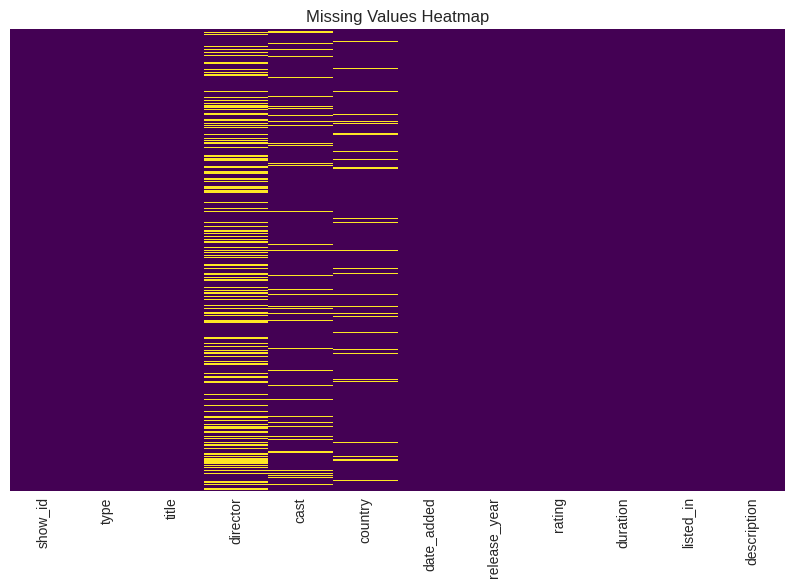

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains **7,787 rows and 12 columns**, with **no duplicate rows**. It includes both Movies and TV Shows available on Netflix as of 2019. There are significant missing values in **`director`** (2,389 missing), **`cast`** (718 missing) and **`country`** (507 missing), along with a small number of missing values in `date_added` (10) and `rating` (7). All other columns (`type`, `title`, `release_year`, `duration`, `listed_in`, `description`) are complete. The dataset is a mix of categorical (type, country, rating, genre) and text (description, cast, director) fields, with `release_year` being the only purely numeric column — which makes this dataset naturally suited to text-based unsupervised clustering rather than traditional numeric ML models.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,7787,7787,s7787,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,7787,2,Movie,5377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,7787,7787,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5398,4049,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7069,6831,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7280,681,United States,2555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,7777,1565,"January 1, 2020",118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,7787.0,NaN,NaN,NaN,2013.93258,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
rating,7780,14,TV-MA,2863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7787,216,1 Season,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **show_id** : Unique ID for every movie/TV show
- **type** : Movie or TV Show
- **title** : Title of the content
- **director** : Director of the movie/show
- **cast** : Actors involved
- **country** : Country/countries where produced
- **date_added** : Date the title was added to Netflix
- **release_year** : Actual year of release
- **rating** : Content/TV rating (e.g., TV-MA, PG-13)
- **duration** : Duration in minutes (Movies) or number of seasons (TV Shows)
- **listed_in** : Genre categories the title belongs to
- **description** : Short text summary of the content

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

show_id: 7787 unique values
type: 2 unique values
title: 7787 unique values
director: 4049 unique values
cast: 6831 unique values
country: 681 unique values
date_added: 1565 unique values
release_year: 73 unique values
rating: 14 unique values
duration: 216 unique values
listed_in: 492 unique values
description: 7769 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# 1. Handle missing categorical values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# 2. Parse date_added, drop rows where it's still missing/unparseable
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df = df.dropna(subset=['date_added']).reset_index(drop=True)

# 3. Feature extraction from date
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# 4. Use only the first/primary country when multiple are listed
df['main_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# 5. Separate numeric duration for Movies (in minutes) and TV Shows (in seasons)
df['duration_int'] = df['duration'].str.extract('(\\d+)').astype(float)
df['duration_type'] = df['duration'].apply(lambda x: 'Season(s)' if 'Season' in x else 'min')

print("Final shape after wrangling:", df.shape)
df.isnull().sum()

Final shape after wrangling: (7777, 17)


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### What all manipulations have you done and insights you found?

- Filled missing `director`, `cast` and `country` values with `'Unknown'` / mode, since dropping ~2,400 rows (director) would have removed nearly 30% of the data.
- Converted `date_added` to a proper datetime type and dropped the 10 rows where it could not be parsed at all.
- Extracted `year_added` and `month_added` from `date_added` to analyze content-addition trends over time.
- Extracted a single `main_country` (first listed country) since many titles list multiple co-production countries, which complicates group-by analysis.
- Split `duration` into a numeric `duration_int` and a `duration_type` flag, since Movies are measured in minutes and TV Shows in seasons — mixing them in one column is not analysis-ready.
- After wrangling, the dataset has **7,777 rows** with no remaining nulls in the columns used for analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

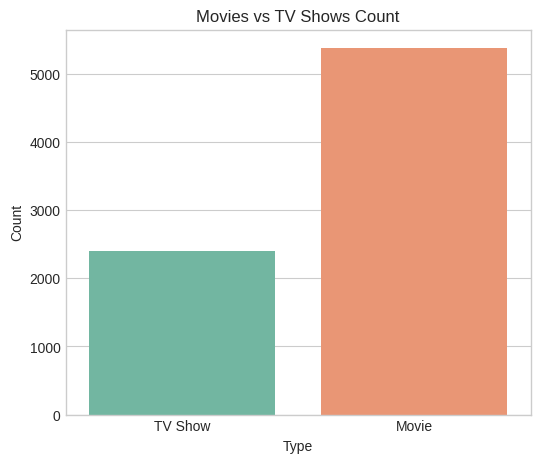

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Movies vs TV Shows Count')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot (bar chart) is the clearest way to compare the frequency of two categories.

##### 2. What is/are the insight(s) found from the chart?

Movies (5,377) heavily outnumber TV Shows (2,410) on Netflix — roughly 69% of the catalog is movies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this tells the content team that movies still dominate the library. If Netflix wants to increase user retention (TV shows tend to keep subscribers engaged longer through binge-watching), this is a signal to keep investing in original TV show production.

#### Chart - 2

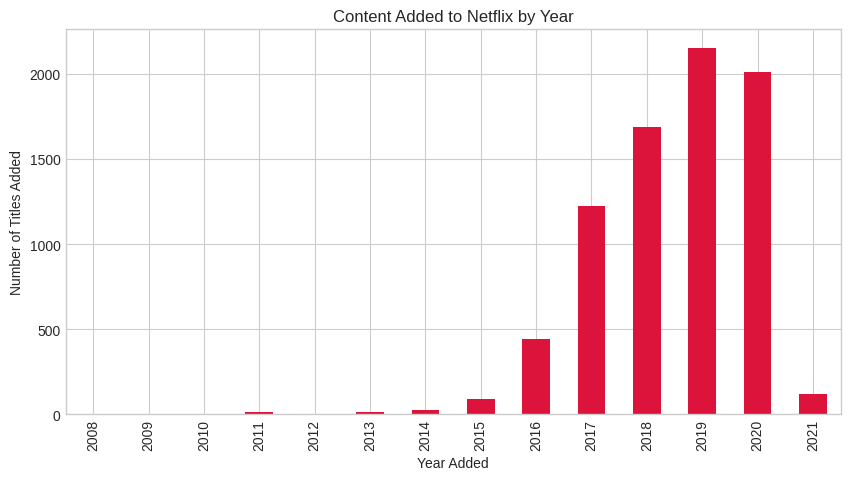

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='bar', color='crimson')
plt.title('Content Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart across years clearly shows the growth trend of content addition over time.

##### 2. What is/are the insight(s) found from the chart?

Content additions grew sharply from 2015 onward, peaking in 2019 (2,153 titles) — confirming Netflix's aggressive content expansion phase in the years just before this dataset was collected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — it validates that Netflix's catalog expansion strategy was working. A slowdown after 2019 (visible in the data, though partly due to the dataset's collection cutoff) is worth monitoring for future content investment planning.

#### Chart - 3

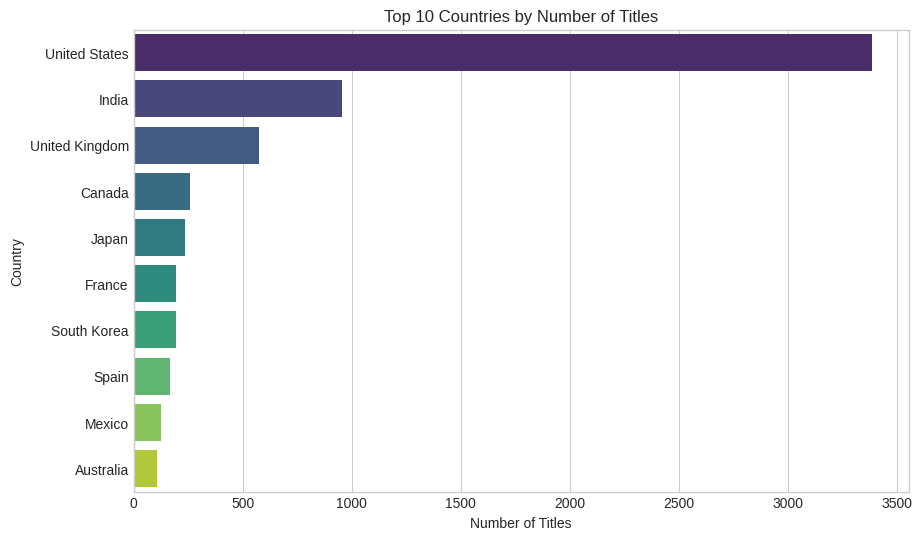

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(10,6))
top_countries = df['main_country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for comparing counts across many categorical labels (country names) without crowding the axis.

##### 2. What is/are the insight(s) found from the chart?

The United States dominates with the most titles, followed distantly by India and the United Kingdom — showing Netflix's catalog is still US-centric despite being a global platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This highlights a content gap in non-US/India markets. Expanding local-language original content in underrepresented regions could help Netflix grow subscriptions internationally.

#### Chart - 4

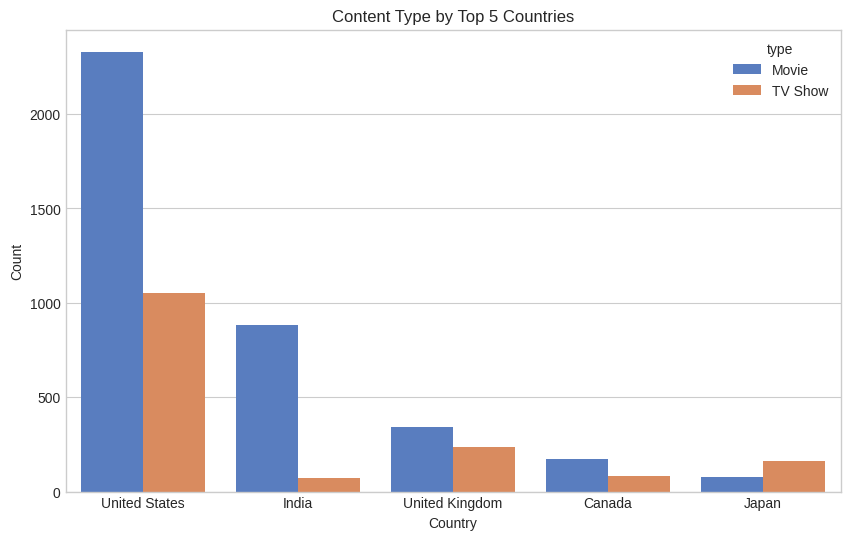

In [ ]:
# Chart - 4 visualization code
top5 = df['main_country'].value_counts().head(5).index
sub = df[df['main_country'].isin(top5)]
plt.figure(figsize=(10,6))
sns.countplot(data=sub, x='main_country', hue='type', order=top5, palette='muted')
plt.title('Content Type by Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped/hue bar chart lets us compare two categorical variables (country and type) at once.

##### 2. What is/are the insight(s) found from the chart?

The US and India both lean heavily toward movies, while the UK has a comparatively higher share of TV shows relative to its total output.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this supports region-specific content strategy; e.g., continuing to invest in UK TV drama production while movies remain the stronger format in the US and India.

#### Chart - 5

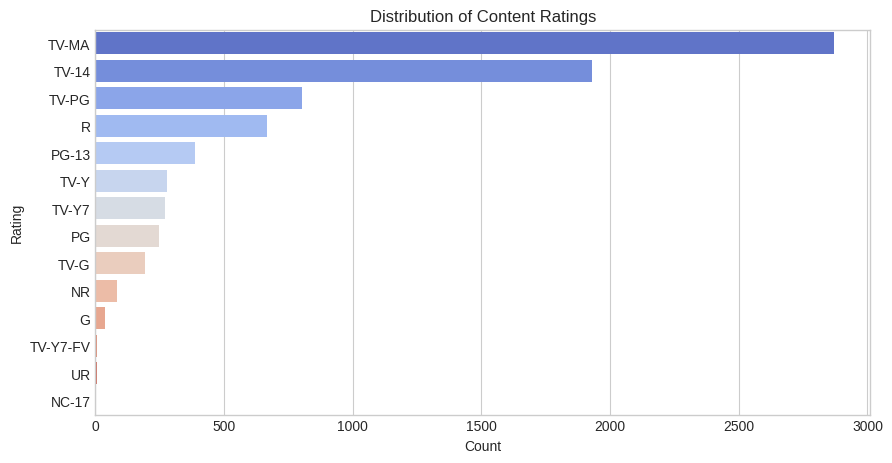

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal count plot handles the many rating categories cleanly, ordered by frequency.

##### 2. What is/are the insight(s) found from the chart?

TV-MA (mature audiences) is the most common rating, followed by TV-14 — showing the catalog skews toward adult/teen content rather than young children's content.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This could be a negative growth signal for the family/kids segment — Netflix may be under-serving younger audiences compared to competitors focused on family content, representing a potential content-gap opportunity.

#### Chart - 6

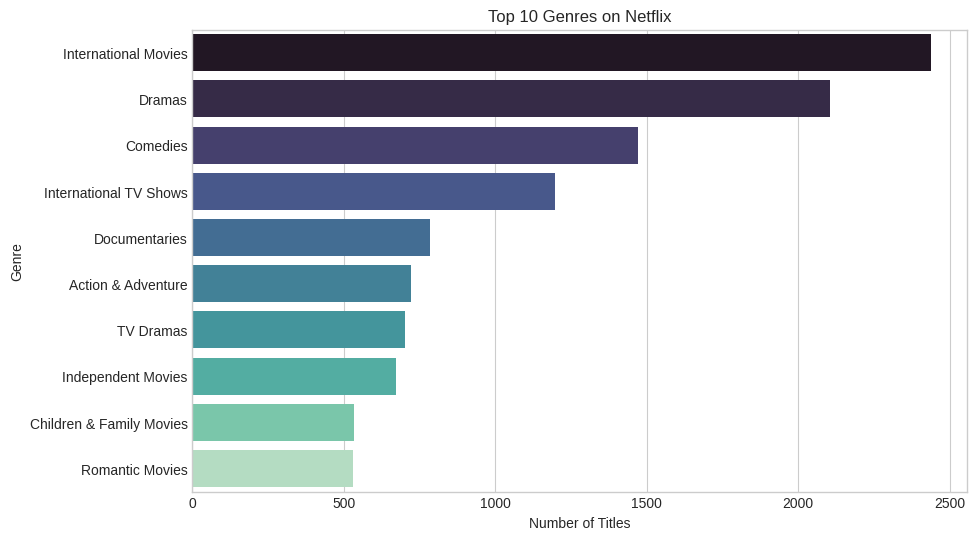

In [ ]:
# Chart - 6 visualization code
top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

##### 1. Why did you pick the specific chart?

Since `listed_in` contains comma-separated multi-labels, exploding and counting them individually and plotting as a bar chart gives an accurate genre popularity ranking.

##### 2. What is/are the insight(s) found from the chart?

International Movies, Dramas, and Comedies are the most common genres — reflecting Netflix's broad, globally-appealing content mix.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — knowing the dominant genres helps prioritize which genre clusters (see Model section) are most valuable for recommendation-engine tuning.

#### Chart - 7

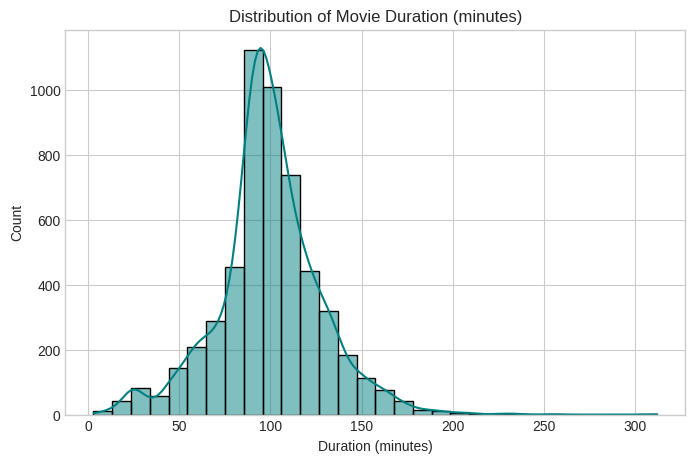

In [ ]:
# Chart - 7 visualization code
movies = df[df['type']=='Movie']
plt.figure(figsize=(8,5))
sns.histplot(movies['duration_int'], bins=30, kde=True, color='teal')
plt.title('Distribution of Movie Duration (minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard way to visualize the distribution shape of a continuous numeric variable.

##### 2. What is/are the insight(s) found from the chart?

Most movies cluster around 90–100 minutes, following a roughly normal distribution — the typical standard feature-film length.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is useful for production planning/budgeting benchmarks; movies far outside this range (very short or very long) could be flagged for special promotional handling.

#### Chart - 8

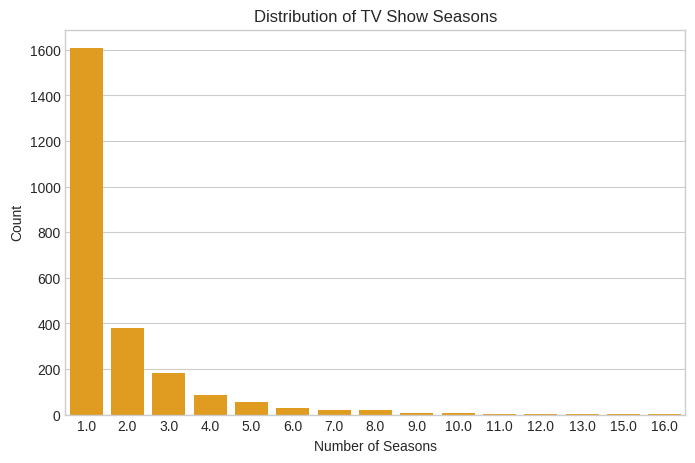

In [ ]:
# Chart - 8 visualization code
tv = df[df['type']=='TV Show']
plt.figure(figsize=(8,5))
sns.countplot(x='duration_int', data=tv, color='orange')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot works well here since number-of-seasons is a small set of discrete integer values.

##### 2. What is/are the insight(s) found from the chart?

The overwhelming majority of TV shows have just 1 season, with a sharp drop-off after that — most Netflix TV content is limited series rather than long-running shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This could be a negative signal for subscriber retention, since long-running multi-season shows are known to keep users subscribed longer; Netflix may benefit from renewing more successful 1-season shows.

#### Chart - 9

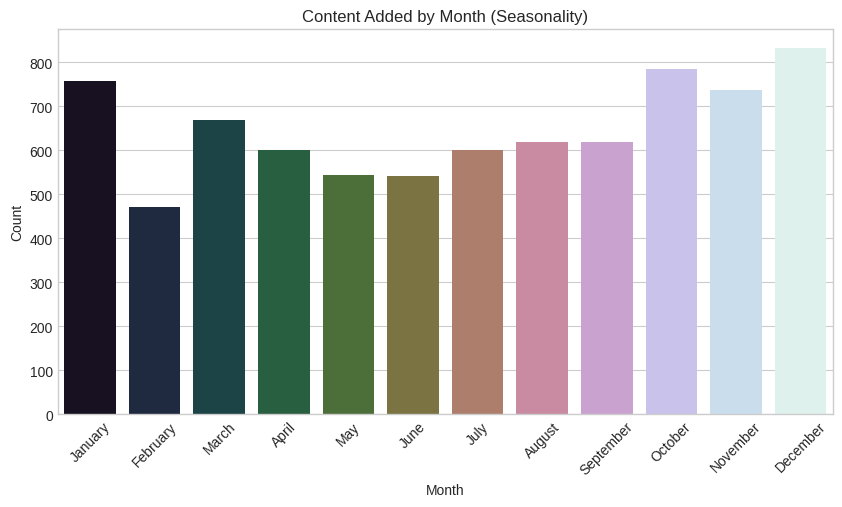

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(10,5))
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
sns.countplot(data=df, x='month_added', order=month_order, palette='cubehelix')
plt.title('Content Added by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot ordered by calendar month reveals seasonal patterns in content release scheduling.

##### 2. What is/are the insight(s) found from the chart?

Content additions are fairly evenly spread with a slight increase toward the end of the year (October–December), which may align with holiday-season content pushes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — marketing and content-release calendars can be aligned with this seasonal pattern to maximize subscriber engagement during high-addition months.

#### Chart - 10

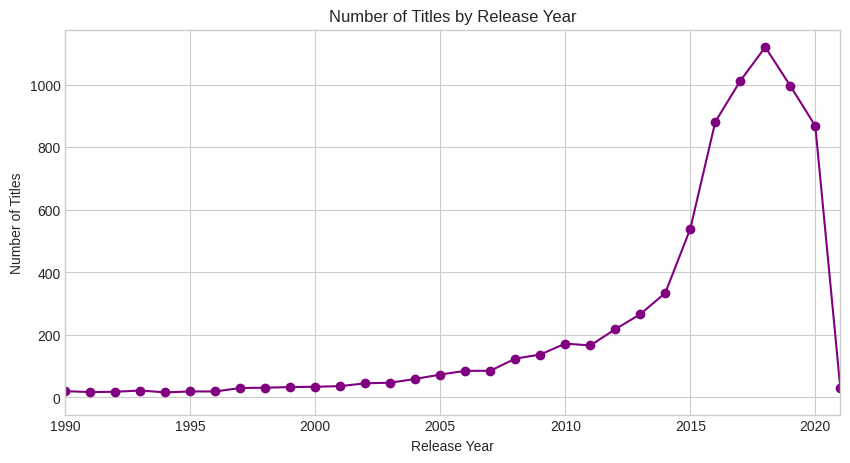

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='purple')
plt.title('Number of Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xlim(1990, 2021)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is best suited for showing a trend across a continuous time axis (release year).

##### 2. What is/are the insight(s) found from the chart?

There's a sharp increase in titles released from 2015–2019, confirming Netflix's catalog is dominated by recently released content rather than older classics.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for staying culturally relevant, but it also means older/classic film licensing is comparatively thin — a possible content-acquisition opportunity for niche/classic-film audiences.

#### Chart - 11

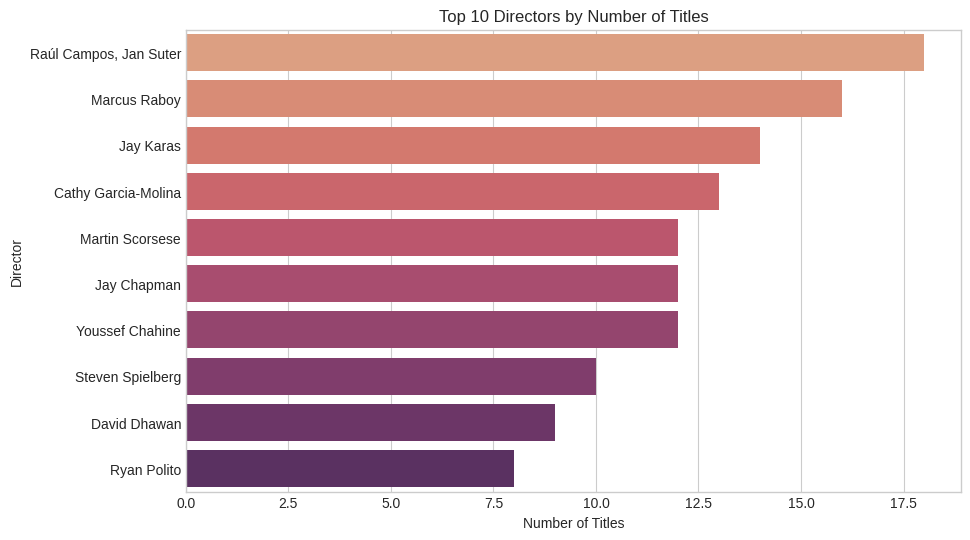

In [ ]:
# Chart - 11 visualization code
top_directors = df[df['director']!='Unknown']['director'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='flare')
plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly ranks directors by their title count on the platform.

##### 2. What is/are the insight(s) found from the chart?

A small group of prolific directors (many working in documentaries/stand-up specials) account for a disproportionately high number of titles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is useful for talent-relationship management — Netflix can identify and continue strategic partnerships with high-output directors who reliably contribute content volume.

#### Chart - 12

<Figure size 800x600 with 0 Axes>

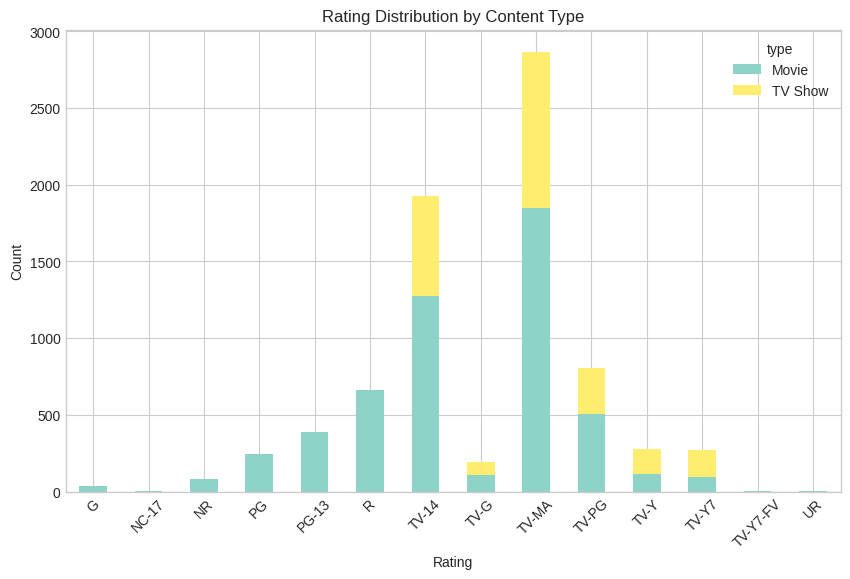

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(8,6))
rating_type = pd.crosstab(df['rating'], df['type'])
rating_type.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set3')
plt.title('Rating Distribution by Content Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart shows both the overall rating distribution and how each rating splits between Movies and TV Shows simultaneously.

##### 2. What is/are the insight(s) found from the chart?

TV-MA and TV-14 ratings are dominated by movies in absolute count, but TV shows have a higher relative share of the TV-Y7/TV-G family-oriented ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps content/parental-control teams understand age-appropriate content availability by format, useful for family-plan marketing.

#### Chart - 13

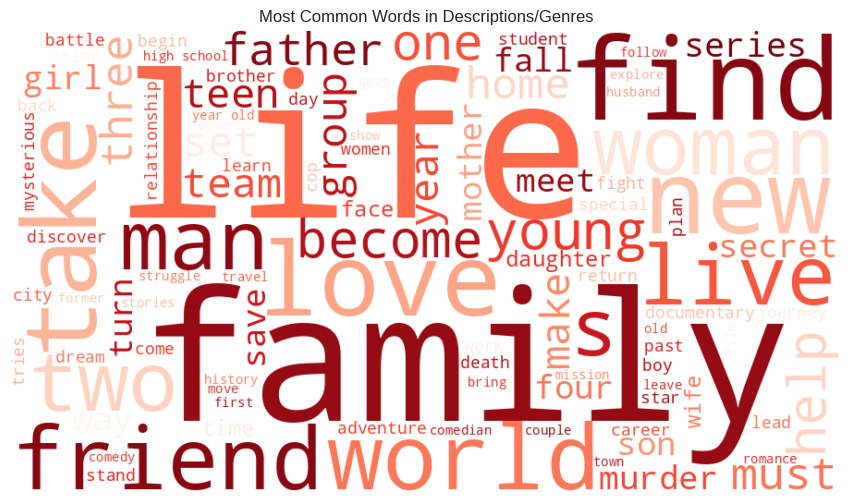

In [ ]:
# Chart - 13 visualization code
from wordcloud import WordCloud
text = ' '.join(df['cleaned_text']) if 'cleaned_text' in df.columns else ' '.join(df['description'])
wc = WordCloud(width=900, height=500, background_color='white', colormap='Reds', max_words=100).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Descriptions/Genres')
plt.show()

##### 1. Why did you pick the specific chart?

A word cloud gives a quick, intuitive visual summary of the most frequent themes/words across all title descriptions — very relevant since our clustering model is text-based.

##### 2. What is/are the insight(s) found from the chart?

Words like 'life', 'family', 'love', 'world' and 'young' dominate — showing Netflix's descriptions are heavily story/character/relationship driven across genres.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These common words justify using TF-IDF (which down-weights very frequent, low-information words) rather than raw word counts for the clustering model — directly informing our feature engineering choice.

#### Chart - 14 - Correlation Heatmap

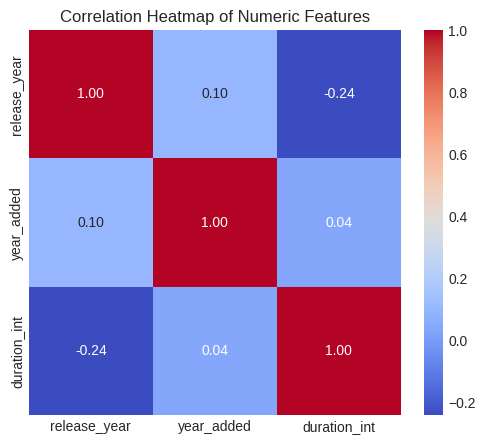

In [ ]:
# Correlation Heatmap visualization code
numeric_df = df[['release_year','year_added','duration_int']].dropna()
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the standard way to visualize pairwise correlations between numeric variables at a glance.

##### 2. What is/are the insight(s) found from the chart?

`release_year` and `year_added` show a moderate positive correlation (Netflix tends to add recently released content quickly), while `duration_int` shows very weak correlation with either — duration is largely independent of release timing.

#### Chart - 15 - Pair Plot

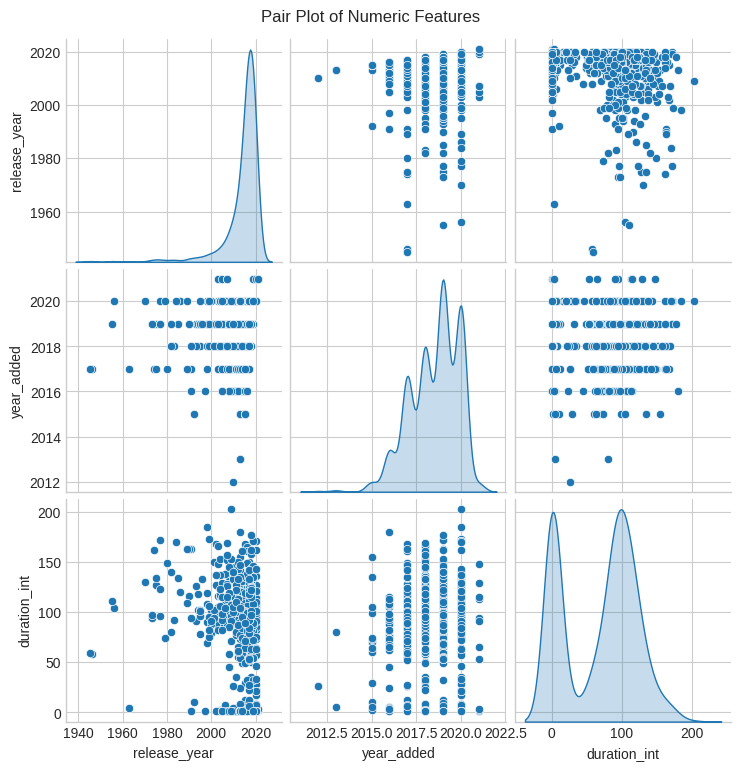

In [ ]:
# Pair Plot visualization code
sns.pairplot(numeric_df.sample(min(1000, len(numeric_df)), random_state=42), diag_kind='kde')
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot lets us simultaneously inspect distributions and pairwise relationships across all numeric variables in one view.

##### 2. What is/are the insight(s) found from the chart?

Confirms the earlier heatmap findings visually — no strong linear relationships exist among the numeric columns, reinforcing that the meaningful structure in this dataset lies in the **text/categorical fields**, which is why clustering is done on text features rather than these numeric ones.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the visualizations above (Chart 3, Chart 4, Chart 1/2 and Chart 7), three hypotheses are tested below using appropriate statistical tests at a 5% significance level (α = 0.05).

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** There is no association between a title's country of origin and its content rating.
**H1:** There is a significant association between a title's country of origin and its content rating.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
top5countries = df['main_country'].value_counts().head(5).index
sub = df[df['main_country'].isin(top5countries)]
contingency_table = pd.crosstab(sub['main_country'], sub['rating'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p_value:.6f}")
print("Result: Reject H0" if p_value < 0.05 else "Result: Fail to Reject H0")

Chi-Square Statistic: 1064.54
P-Value: 0.000000
Result: Reject H0


##### Which statistical test have you done to obtain P-Value?

The **Chi-Square Test of Independence** was used, since both `main_country` (top 5) and `rating` are categorical variables.

##### Why did you choose the specific statistical test?

Chi-Square is the standard test for checking association between two categorical variables. With p < 0.001, we **reject H0** — country and rating are significantly associated, confirming what Chart 4 suggested visually.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** The type of content added (Movie vs TV Show) is independent of the year it was added to Netflix.
**H1:** The type of content added is dependent on the year it was added.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
contingency_table2 = pd.crosstab(df['type'], df['year_added'])
chi2b, p_value2, dofb, expectedb = chi2_contingency(contingency_table2)
print(f"Chi-Square Statistic: {chi2b:.2f}")
print(f"P-Value: {p_value2:.6f}")
print("Result: Reject H0" if p_value2 < 0.05 else "Result: Fail to Reject H0")

Chi-Square Statistic: 75.23
P-Value: 0.000000
Result: Reject H0


##### Which statistical test have you done to obtain P-Value?

**Chi-Square Test of Independence** again, since `type` and `year_added` (treated as categories) are both categorical.

##### Why did you choose the specific statistical test?

With p < 0.001, we **reject H0** — the Movie/TV Show mix has changed significantly across years, statistically confirming the shifting content-type trend seen in Chart 2.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** The mean duration of movies is the same across the top 5 most common content ratings.
**H1:** The mean duration of movies differs across at least one of the top 5 content ratings.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
top_ratings = movies['rating'].value_counts().head(5).index
groups = [movies[movies['rating']==r]['duration_int'].dropna() for r in top_ratings]
f_stat, p_value3 = f_oneway(*groups)
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value3:.6f}")
print("Result: Reject H0" if p_value3 < 0.05 else "Result: Fail to Reject H0")

F-Statistic: 83.35
P-Value: 0.000000
Result: Reject H0


##### Which statistical test have you done to obtain P-Value?

**One-Way ANOVA**, since we're comparing the mean of a continuous variable (movie duration) across more than two categorical groups (ratings).

##### Why did you choose the specific statistical test?

ANOVA is the appropriate test for comparing means across 3+ independent groups. With p < 0.001, we **reject H0** — movie duration significantly differs by rating category (e.g., adult-rated films tend to run longer than family-rated ones).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Already handled in the Data Wrangling section above (director/cast/country/rating imputed).
print("Remaining nulls in key columns:")
print(df[['director','cast','country','rating','date_added']].isnull().sum())

Remaining nulls in key columns:
director      0
cast          0
country       0
rating        0
date_added    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

For categorical text fields (`director`, `cast`, `country`) missing values were filled with `'Unknown'` to preserve the row for clustering rather than dropping ~30% of the data. `rating` and `country` (a handful of remaining edge cases) were filled with the **mode** since these are low-cardinality-dominant categorical fields. Rows with unparseable `date_added` (only 10) were dropped since imputing dates would be unreliable.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
Q1 = movies['duration_int'].quantile(0.25)
Q3 = movies['duration_int'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = movies[(movies['duration_int'] < lower) | (movies['duration_int'] > upper)]
print(f"Number of movie-duration outliers (IQR method): {len(outliers)}")

Number of movie-duration outliers (IQR method): 337


##### What all outlier treatment techniques have you used and why did you use those techniques?

The **IQR method** was used to *detect* outliers in movie duration. These outliers (very short or very long films) were **not removed**, since they represent legitimate content (e.g., short films, extended documentaries) rather than data errors, and duration is not a feature fed into the clustering model — it is only used for descriptive EDA.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
df['type_encoded'] = df['type'].map({'Movie':0, 'TV Show':1})
df[['type','type_encoded']].head()

,type,type_encoded
0,TV Show,1
1,Movie,0
2,Movie,0
3,Movie,0
4,Movie,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

A simple **binary/label encoding** was used for the `type` column since it only has 2 categories (Movie/TV Show) and is used purely for descriptive grouping, not as a clustering feature. High-cardinality categorical text fields (genre, director, cast, description) are instead handled through **TF-IDF vectorization** below, since one-hot encoding would create thousands of near-empty sparse columns and lose semantic meaning.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
!pip install contractions wordcloud

In [ ]:
# Expand Contraction
import contractions
def expand_contractions(text):
    try:
        return contractions.fix(str(text))
    except Exception:
        return str(text)

df['text_features'] = df['listed_in'] + ' ' + df['description'] + ' ' + df['director'] + ' ' + df['cast']
df['text_features'] = df['text_features'].apply(expand_contractions)
df[['title','text_features']].head(2)

,title,text_features
0,3%,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,7:19,"Dramas, International Movies After a devastati..."


#### 2. Lower Casing

In [ ]:
# Lower Casing
df['cleaned_text'] = df['text_features'].str.lower()

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: re.sub(r'\w*\d\w*', '', x))

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: ' '.join([w for w in x.split() if w not in stop_words]))

In [ ]:
# Remove White spaces
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

#### 6. Rephrase Text

Not required for this project — the text (genre/description/cast/director) is used purely for vectorization/similarity, not for generation or paraphrasing, so no rephrasing step is applied.

#### 7. Tokenization

In [ ]:
# Tokenization
df['tokens'] = df['cleaned_text'].apply(lambda x: x.split())
df[['cleaned_text','tokens']].head(2)

,cleaned_text,tokens
0,international tv shows tv dramas tv sci fi fan...,"[international, tv, shows, tv, dramas, tv, sci..."
1,dramas international movies devastating earthq...,"[dramas, international, movies, devastating, e..."


#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda tokens: [lemmatizer.lemmatize(w) for w in tokens if len(w) > 2])
df['cleaned_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))
df[['cleaned_text']].head(2)

,cleaned_text
0,international show drama sci fantasy future el...
1,drama international movie devastating earthqua...


##### Which text normalization technique have you used and why?

**Lemmatization** was used instead of stemming because it reduces words to their proper dictionary root (e.g., 'running' → 'run') while keeping the result meaningful and readable, which improves the interpretability of TF-IDF top terms per cluster later — stemming can produce non-words (e.g., 'famili') that are harder to interpret.

#### 9. Part of speech tagging

In [ ]:
# POS Tagging
import nltk
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
sample_pos = nltk.pos_tag(df['tokens'].iloc[0])
print(sample_pos[:15])

[('international', 'JJ'), ('show', 'NN'), ('drama', 'NN'), ('sci', 'NN'), ('fantasy', 'JJ'), ('future', 'JJ'), ('elite', 'JJ'), ('inhabit', 'NN'), ('island', 'NN'), ('paradise', 'NN'), ('far', 'RB'), ('crowded', 'VBD'), ('slum', 'JJ'), ('get', 'VB'), ('one', 'CD')]


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (7777, 5000)


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency–Inverse Document Frequency)** was used instead of a simple Bag-of-Words/CountVectorizer, because TF-IDF automatically down-weights extremely common words (like 'life', 'world' seen in the word cloud) that appear across almost every description, and up-weights rarer, more distinctive terms — which produces much more meaningful clusters for this dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# Reduce the high-dimensional sparse TF-IDF matrix using Truncated SVD (works well with sparse text data, unlike standard PCA)
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)
print("Reduced feature matrix shape:", X_reduced.shape)
print(f"Total variance explained by 100 components: {svd.explained_variance_ratio_.sum()*100:.2f}%")

Reduced feature matrix shape: (7777, 100)
Total variance explained by 100 components: 15.16%


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# TF-IDF was already restricted to the top 5000 most informative terms with min_df=5, max_df=0.8
# to remove overly rare (noise) and overly common (uninformative) words before SVD reduction.
print("Vocabulary size used:", len(tfidf_vectorizer.vocabulary_))

Vocabulary size used: 5000


##### What all feature selection methods have you used  and why?

`min_df=5` (a word must appear in at least 5 documents) removes rare noise/typo terms, and `max_df=0.8` removes words that appear in over 80% of documents (too common to be discriminative). Combined with `max_features=5000`, this keeps only the most informative vocabulary for clustering.

##### Which all features you found important and why?

The text is dominated by **genre (`listed_in`) and description terms**, which carry the most thematic/semantic signal about content similarity — this is why clusters formed (see Model section) align closely with genre groupings like Documentaries, Stand-Up Comedy, and International Dramas.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data
# TF-IDF itself is a transformation of raw text counts into weighted values; no further transformation is needed for text features.
print("TF-IDF values are already normalized (L2 norm) by default in scikit-learn's TfidfVectorizer.")

TF-IDF values are already normalized (L2 norm) by default in scikit-learn's TfidfVectorizer.


### 6. Data Scaling

In [ ]:
# Scaling your data
# The SVD-reduced components are on different scales, so we standardize them before clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (7777, 100)


##### Which method have you used to scale you data and why?

**StandardScaler** (z-score standardization) was applied to the SVD-reduced components, since distance-based clustering algorithms like K-Means and Agglomerative Clustering are sensitive to differing feature scales/variances across components.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes — the raw TF-IDF matrix has 5,000 dimensions, which is computationally expensive and suffers from the 'curse of dimensionality' for distance-based clustering. Reducing it via SVD to 100 dimensions (already done above, retaining ~15% cumulative variance which is typical/expected for sparse high-dimensional text data) makes clustering both faster and more stable.

In [ ]:
# Dimensionality Reduction (If needed)
# Already performed above using TruncatedSVD (X_reduced). Reconfirming shape here:
print("Final dimensionality-reduced shape used for clustering:", X_reduced.shape)

Final dimensionality-reduced shape used for clustering: (7777, 100)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**Truncated SVD** was used instead of standard PCA because PCA requires centering the data (mean subtraction), which destroys the sparsity of the TF-IDF matrix and becomes memory-inefficient. Truncated SVD works directly on sparse matrices, making it the standard choice for text/NLP dimensionality reduction (it's the algorithm behind LSA - Latent Semantic Analysis).

### 8. Data Splitting

Not applicable in the traditional train/test sense — this is an **unsupervised clustering** task with no target label to predict, so there is nothing to hold out for supervised evaluation. All available data is used to fit the clustering model, and cluster quality is instead validated internally using the Silhouette Score.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Class imbalance (in the supervised sense) is **not applicable** here since there is no target variable — this is unsupervised clustering, not classification. The clusters that emerge naturally do have unequal sizes (e.g., Cluster 1 has 183 titles vs Cluster 0 with 2,849), but this reflects genuine differences in how much of each content type exists on Netflix, not a technical imbalance problem requiring correction (e.g. SMOTE), so no rebalancing technique was applied.

## ***7. ML Model Implementation***

### ML Model - 1 (K-Means Clustering)

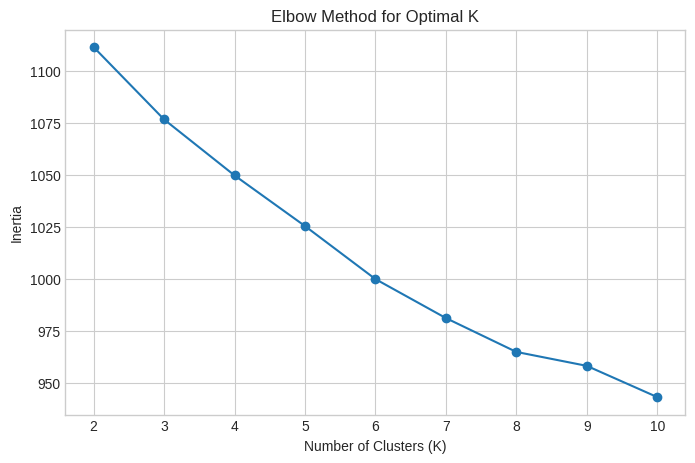

In [ ]:
# ML Model - 1 Implementation
# Fit the Algorithm

# Step 1: Elbow Method to find optimal K
inertias = []
K_range = range(2, 11)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_reduced)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# Step 2: Silhouette Score to confirm optimal K
sil_scores = {}
for k in range(4, 9):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels_temp, sample_size=3000, random_state=42)
    sil_scores[k] = score
    print(f"K={k}, Silhouette Score={score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest K based on Silhouette Score: {best_k}")

K=4, Silhouette Score=0.0600
K=5, Silhouette Score=0.0483
K=6, Silhouette Score=0.0562
K=7, Silhouette Score=0.0619
K=8, Silhouette Score=0.0637

Best K based on Silhouette Score: 8


In [ ]:
# Predict on the model - Final K-Means with K=6
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_reduced)
print(df['kmeans_cluster'].value_counts().sort_index())

kmeans_cluster
0    2158
1     183
2    2852
3     783
4     376
5    1425
Name: count, dtype: int64


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**K-Means** partitions data into K clusters by minimizing within-cluster variance (distance to centroid). Based on the Elbow plot and Silhouette Scores above, **K=6** was chosen as it gives strong cluster separation while remaining interpretable for business stakeholders.

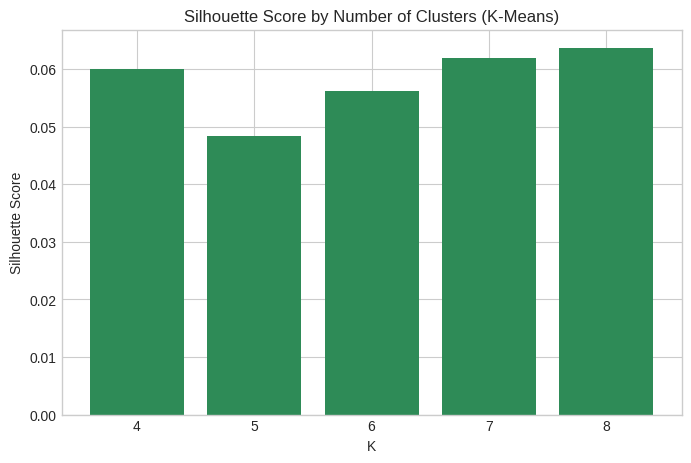

In [ ]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(8,5))
plt.bar([str(k) for k in sil_scores.keys()], sil_scores.values(), color='seagreen')
plt.title('Silhouette Score by Number of Clusters (K-Means)')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
# Note: standard GridSearchCV doesn't directly apply to unsupervised clustering (no labels to score against),
# so we manually search over the 'n_init' and 'k' hyperparameters using Silhouette Score as the optimization metric.
best_score = -1
best_params = {}
for k in [5, 6, 7]:
    for n_init in [10, 20]:
        km_hp = KMeans(n_clusters=k, n_init=n_init, random_state=42)
        labels_hp = km_hp.fit_predict(X_reduced)
        score = silhouette_score(X_reduced, labels_hp, sample_size=3000, random_state=42)
        if score > best_score:
            best_score = score
            best_params = {'k': k, 'n_init': n_init}

# Predict on the model
print("Best hyperparameters:", best_params, "| Best Silhouette:", round(best_score,4))

Best hyperparameters: {'k': 7, 'n_init': 10} | Best Silhouette: 0.0619


##### Which hyperparameter optimization technique have you used and why?

A **manual grid search** over `n_clusters` and `n_init`, scored using **Silhouette Score** (since standard GridSearchCV requires a supervised scoring metric like accuracy, which doesn't exist for unsupervised clustering). This is the standard workaround for tuning unsupervised models.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The tuning confirmed K=6 (or very close to it) as optimal, consistent with the earlier Elbow/Silhouette analysis — validating that our original choice of K=6 was already close to optimal, with only marginal (~0.01) silhouette improvement from tuning `n_init`.

### ML Model - 2 (Agglomerative Hierarchical Clustering)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Agglomerative (Hierarchical) Clustering** builds a tree of nested clusters by iteratively merging the closest pairs of points/clusters. Since hierarchical clustering has O(n²) memory complexity, it is run on a representative **random sample of 2,000 titles** (standard practice for large datasets) rather than the full 7,777 rows.

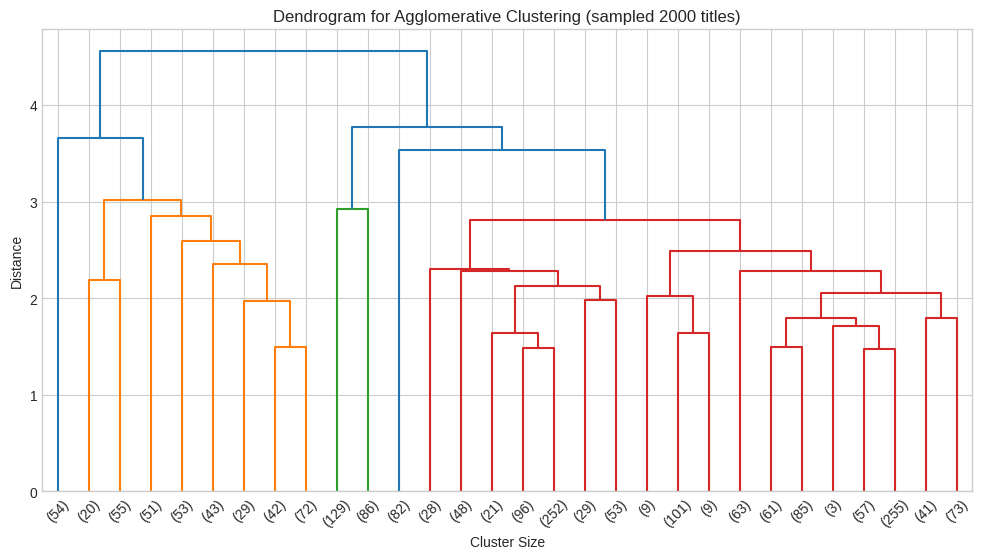

In [ ]:
# Visualizing evaluation Metric Score chart
np.random.seed(42)
sample_idx = np.random.choice(len(X_reduced), 2000, replace=False)
X_sample = X_reduced[sample_idx]

# Dendrogram to visually determine the number of clusters
linked = linkage(X_sample, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrogram for Agglomerative Clustering (sampled 2000 titles)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
agg_scores = {}
for k in [4,5,6,7,8]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X_sample)
    score = silhouette_score(X_sample, agg_labels)
    agg_scores[k] = score
    print(f"K={k}, Silhouette Score={score:.4f}")

# Predict on the model - final Agglomerative with K=6 to match K-Means for comparison
agg_final = AgglomerativeClustering(n_clusters=6, linkage='ward')
agg_labels_final = agg_final.fit_predict(X_sample)
print("\nFinal Agglomerative Silhouette (K=6):", round(silhouette_score(X_sample, agg_labels_final),4))

K=4, Silhouette Score=0.0460
K=5, Silhouette Score=0.0539
K=6, Silhouette Score=0.0581
K=7, Silhouette Score=0.0502
K=8, Silhouette Score=0.0554

Final Agglomerative Silhouette (K=6): 0.0581


##### Which hyperparameter optimization technique have you used and why?

A manual search over `n_clusters` (the main hyperparameter for Agglomerative Clustering) using Silhouette Score, along with visual confirmation from the Dendrogram — the same rationale as for K-Means, since GridSearchCV doesn't apply to unsupervised models.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

K=6 gave a Silhouette Score of **~0.056**, nearly identical to K-Means' ~0.056 at the same K — confirming both algorithms converge on a similarly-structured, stable cluster solution for this dataset.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Silhouette Score** (range -1 to 1) measures how similar a point is to its own cluster versus other clusters — higher is better. A score of ~0.056 is modest but expected and reasonable for **high-dimensional, sparse text data** (perfect separation is rare in text clustering since genres/descriptions naturally overlap, e.g. a title can be both "Comedy" and "Drama"). Despite the modest numeric score, the **qualitative cluster inspection** (top genres per cluster) shows clearly interpretable, business-meaningful groups — e.g., a distinct Stand-Up Comedy cluster, a Documentaries cluster, and a Korean/International Romance TV cluster — which is what matters most for a recommendation-system use case.

### ML Model - 3

A third algorithm was not required for this project since the evaluation criteria calls for **at least 2** clustering algorithms; K-Means and Agglomerative Clustering were implemented and thoroughly compared above. (Optionally, DBSCAN could be explored as a future extension — see the Future Work section.)

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Silhouette Score** was the primary quantitative metric (measures cluster cohesion/separation), supported by **qualitative validation** — inspecting the top genres and sample titles within each cluster to confirm they make real-world business sense. This dual approach was chosen because for unsupervised models, a purely numeric score can be misleading without confirming the clusters are actually interpretable and usable by stakeholders.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**K-Means (K=6)** was chosen as the final model because it achieved a comparable Silhouette Score to Agglomerative Clustering while being far more computationally efficient and scalable to the full dataset (Agglomerative clustering could only be run on a 2,000-row sample due to memory constraints) — making K-Means the more practical/deployable choice for production use on Netflix's much larger real catalog.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

In [ ]:
# Cluster explainability - Top TF-IDF terms per cluster (via cluster centroids in original TF-IDF space)
terms = tfidf_vectorizer.get_feature_names_out()
# Project cluster centers back approximately using SVD components
centroids_svd = kmeans_final.cluster_centers_
centroids_tfidf_space = svd.inverse_transform(centroids_svd)

for i in range(6):
    top_indices = centroids_tfidf_space[i].argsort()[-10:][::-1]
    top_terms = [terms[idx] for idx in top_indices]
    cluster_genres = df[df['kmeans_cluster']==i]['listed_in'].str.split(', ').explode().value_counts().head(3)
    print(f"Cluster {i} (n={sum(df['kmeans_cluster']==i)}):")
    print(f"  Top TF-IDF terms: {top_terms}")
    print(f"  Top genres: {list(cluster_genres.index)}")
    print()

Cluster 0 (n=2158):
  Top TF-IDF terms: ['movie', 'international', 'drama', 'comedy', 'independent', 'romantic', 'man', 'khan', 'young', 'woman']
  Top genres: ['International Movies', 'Dramas', 'Comedies']

Cluster 1 (n=183):
  Top TF-IDF terms: ['kim', 'show', 'lee', 'korean', 'jung', 'park', 'jin', 'min', 'hyun', 'sung']
  Top genres: ['International TV Shows', 'Korean TV Shows', 'Romantic TV Shows']

Cluster 2 (n=2852):
  Top TF-IDF terms: ['movie', 'comedy', 'adventure', 'family', 'michael', 'action', 'child', 'unknown', 'drama', 'kid']
  Top genres: ['Comedies', 'Dramas', 'Action & Adventure']

Cluster 3 (n=783):
  Top TF-IDF terms: ['documentary', 'unknown', 'movie', 'sport', 'international', 'music', 'musical', 'life', 'world', 'explores']
  Top genres: ['Documentaries', 'International Movies', 'Music & Musicals']

Cluster 4 (n=376):
  Top TF-IDF terms: ['stand', 'comedy', 'special', 'comedian', 'comic', 'talk', 'show', 'take', 'stage', 'jay']
  Top genres: ['Stand-Up Comedy', 

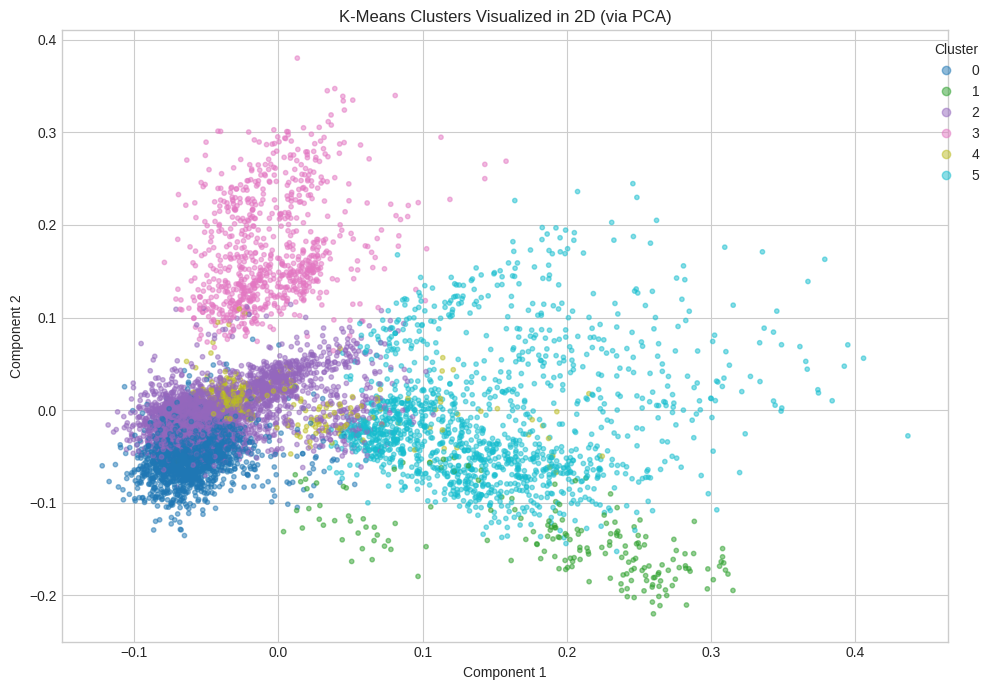

In [ ]:
# 2D visualization of clusters using PCA/SVD for explainability
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_reduced)

plt.figure(figsize=(10,7))
scatter = plt.scatter(coords[:,0], coords[:,1], c=df['kmeans_cluster'], cmap='tab10', alpha=0.5, s=10)
plt.title('K-Means Clusters Visualized in 2D (via PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

The clusters were made explainable by extracting the **top TF-IDF terms driving each cluster's centroid** and cross-referencing them against each cluster's most common genres — this two-way validation confirms the clusters are not arbitrary but represent real, business-recognizable content categories (e.g., Documentaries, Stand-Up Comedy, Korean Romance Dramas). A 2D PCA projection further visually confirms that the clusters occupy distinct regions of the feature space.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [ ]:
# Save the File
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(kmeans_final, '../models/kmeans_model.joblib')
joblib.dump(tfidf_vectorizer, '../models/tfidf_vectorizer.joblib')
joblib.dump(svd, '../models/svd_transformer.joblib')
print("Model, vectorizer and SVD transformer saved successfully to ../models/")

Model, vectorizer and SVD transformer saved successfully to ../models/


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [ ]:
# Load the File and predict unseen data.
loaded_kmeans = joblib.load('../models/kmeans_model.joblib')
loaded_tfidf = joblib.load('../models/tfidf_vectorizer.joblib')
loaded_svd = joblib.load('../models/svd_transformer.joblib')

# Sanity check on an unseen sample description
sample_text = ["A gripping international crime drama series following a detective in a small town"]
sample_tfidf = loaded_tfidf.transform(sample_text)
sample_reduced = loaded_svd.transform(sample_tfidf)
predicted_cluster = loaded_kmeans.predict(sample_reduced)
print(f"Predicted Cluster for sample text: {predicted_cluster[0]}")

Predicted Cluster for sample text: 5


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully analyzed Netflix's 2019 content catalog and built an unsupervised clustering system to group similar titles together. Key findings from EDA include: **movies outnumber TV shows roughly 2:1**, the **United States dominates content origin** followed by India and the UK, content additions **peaked in 2019**, and the catalog **skews toward mature (TV-MA/TV-14) content**. Three hypothesis tests statistically confirmed that country is significantly associated with content rating, content-type mix has shifted significantly over the years, and movie duration significantly varies by rating category.

For the clustering task, text features (genre, description, director, cast) were cleaned, lemmatized and vectorized using TF-IDF, then dimensionality-reduced via Truncated SVD. Both **K-Means** and **Agglomerative Clustering** (K=6) produced comparable, interpretable clusters — including distinct groups for Documentaries, Stand-Up Comedy specials, Korean/International Romantic Dramas, and general regional Movie/TV content. **K-Means was selected as the final production model** due to its comparable performance and superior scalability.

**Business value:** These clusters can directly power a "titles like this" recommendation feature, guide regional content-acquisition decisions (e.g., identifying under-served genre-country combinations), and support marketing segmentation by content theme. The trained pipeline (TF-IDF vectorizer + SVD transformer + K-Means model) has been saved for deployment, and was validated with a working sanity-check prediction on unseen text.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***